# Data Cleaning

## Import Necessary Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("train.csv")

## Dropping Columns

In [ ]:
df = df.drop(columns = 'Id')

The column containing the row id is dropped because it has no predictive value.

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [ ]:
df = df.drop(columns = ['MiscFeature', 'PoolQC', 'Alley', 'Fence'])

Columns like MiscFeature, PoolQC, Alley, and Fence have more than 70% of their values missing. Keeping these values can cause noise, and they also have low predictive value, so they will be dropped.

In [ ]:
num_cols = ['LotFrontage', 'MasVnrArea']

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Numerical Columns with missing values like 'LotFrontage' and 'MasVnrArea' will be filled with the median value of the column.

In [ ]:
cat_cols = ['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'Electrical', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']

df[cat_cols] = df[cat_cols].fillna("None")

Categorical columns with missing values like 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'Electrical', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', and 'GarageCond' will be filled with "None".

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


All missing values have been filled.

In [ ]:
df.duplicated().sum()

np.int64(0)

This dataset has no duplicated values.

In [ ]:
df.shape

(1460, 76)

The dataset now has 76 columns.

## Checking for Outliers

In [ ]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1
median = df['SalePrice'].median()
upper_bound = Q3 + 1.5 * IQR

print(f"25% of the houses are sold below ${Q1}")
print(f"75% of the houses are sold below ${Q3}")
print(f"${median} is the midpoint price.")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {(df['SalePrice'] > upper_bound).sum()}")

25% of the houses are sold below $129975.0
75% of the houses are sold below $214000.0
$163000.0 is the midpoint price.
Upper bound: 340037.5
Number of outliers: 61


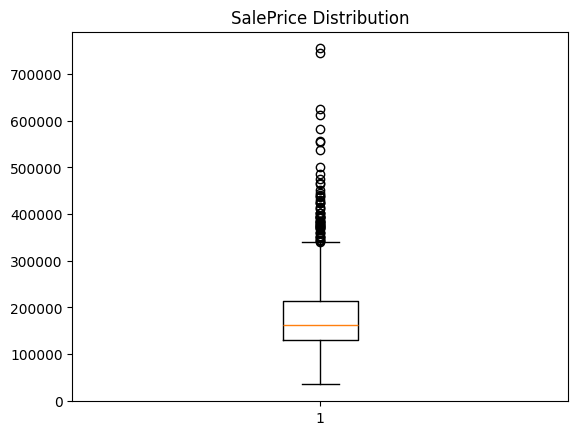

In [ ]:
plt.boxplot(df['SalePrice'])
plt.title('SalePrice Distribution')
plt.show()

The above boxplot illustrates a right-skewed sales price distribution, with several high-value outliers exceeding 340,000 USD. The median sale price is 163,000 USD, with most homes falling between 130,000 USD and 214,000 USD.

Although 61 outliers were identified above the upper bound of $340,037.50 using the IQR method, they were retained in the dataset. These properties, while expensive, represent legitimate real-world sales and removing them could cause the model to underperform on higher-priced homes. The outliers will be noted as a limitation during model evaluation in Task 5.
Another alternative is to perform log transformation on the SalePrice column to reduce the effect of skewness, but that will be explored in a later task.

In [ ]:
df.to_csv("clean_train.csv", index = False)

## In Summary:

The dataset was cleaned through the following steps:

Dropped the Id column as it has no predictive value

Dropped columns with more than 70% missing values (MiscFeature, PoolQC, Alley, Fence)

Filled numerical missing values with median

Filled categorical missing values with 'None'

Confirmed no duplicate rows exist

Checked for outliers

Cleaned dataset saved as clean_train.csv